This notebook follows on from `02_exploratory_analysis.ipynb`. The exploratory work showed the *what* and *where* of AI funding; here we ask the *why*.

### Two complementary models

| Model | Target | Question |
|-------|--------|----------|
| **OLS** | `log(total_funding)` | What predicts the **size** of total funding raised? |
| **Logit** | `P(mega_round)` | What predicts the **probability** of raising a $50M+ round? |

Plus: VIF check, OLS diagnostics, robustness checks (excluding mega-outliers, finer geography, interactions), and a Random Forest sanity-check on feature importance.

---

## 1: Setup, Feature Engineering & Multicollinearity Check

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))  # so we can import src.modeling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

from src.modeling import (
    build_design_matrix, compute_vif, coef_forest_plot,
    fit_logit_with_or, fit_ols_with_pct,
)

Path('../outputs/figures').mkdir(parents=True, exist_ok=True)
Path('../outputs/tables').mkdir(parents=True, exist_ok=True)

# Style (matches notebook 02)
NAVY, BLUE, LBLUE = '#08306b', '#2171b5', '#9ecae1'
ORANGE, RED, GREY = '#e6550d', '#d62728', '#636363'
GREEN = '#31a354'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'axes.labelsize': 11.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.6,
    'axes.axisbelow': True,
    'xtick.major.size': 0,
    'ytick.major.size': 0,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})
print('Setup complete')

Setup complete


In [3]:
df = pd.read_csv('../data/processed/ai_companies_cleaned.csv')

# Derived features 
df['top_tier']    = (df['top_tier_investor'] == 'Y').astype(int)
# Robust log target: handle zeros / very small values
df['log_funding'] = np.log(df['total_funding_millions'].clip(lower=0.001) + 1)
# Interaction terms
df['llm_x_bayarea']   = df['is_llm']   * df['is_bay_area']
df['toptier_x_usa']   = df['top_tier'] * (df['is_usa'] | df['is_bay_area']).astype(int)
df['agent_x_toptier'] = df['is_agent'] * df['top_tier']

print(f'Companies: {len(df):,}')
print(f'Mega-rounds: {df["has_mega_round"].sum()} ({df["has_mega_round"].mean():.1%})')
print(f'log(funding) \u2014 mean: {df["log_funding"].mean():.2f}, std: {df["log_funding"].std():.2f}')
print(f'Top-tier-backed: {df["top_tier"].sum()} ({df["top_tier"].mean():.1%})')

Companies: 502
Mega-rounds: 175 (34.9%)
log(funding) — mean: 3.37, std: 2.09
Top-tier-backed: 165 (32.9%)


In [21]:
FEATURES = {
    'Bay Area':             'is_bay_area',
    'USA (excl. Bay Area)': 'is_usa',
    'London':               'is_london',
    'NYC':                  'is_nyc',
    'Top-Tier Investor':    'top_tier',
    'Enterprise AI':        'is_enterprise_ai',
    'Agent AI':             'is_agent',
    'MLOps':                'is_mlops',
    'Health AI':            'is_health_ai',
    'Finance AI':           'is_fin_ai',
    'Company Age (yrs)':    'company_age_years',
    'Number of Rounds':     'num_rounds',
}

X_logit, y_mega = build_design_matrix(df, FEATURES, 'has_mega_round')
X_ols,   y_log  = build_design_matrix(df, FEATURES, 'log_funding')

print(f'Logit sample: n={len(y_mega):,}  (mega-round rate: {y_mega.mean():.1%})')
print(f'OLS   sample: n={len(y_log):,}   (log-funding mean: {y_log.mean():.2f})')

vif = compute_vif(X_logit)
print('\n── VIF check (>5 = potential multicollinearity) ──')
print(vif.to_string(index=False))
if vif['flag'].any():
    flagged = ', '.join(vif.loc[vif['flag'], 'feature'].tolist())
    print(f'\n Flagged: {flagged}')
else:
    print('\n No features exceed VIF=5 — multicollinearity is not a concern.')

Logit sample: n=384  (mega-round rate: 39.1%)
OLS   sample: n=384   (log-funding mean: 3.61)

── VIF check (>5 = potential multicollinearity) ──
             feature      vif  flag
USA (excl. Bay Area) 3.190667 False
    Number of Rounds 2.963332 False
   Company Age (yrs) 2.613528 False
            Bay Area 2.233204 False
   Top-Tier Investor 2.145913 False
                 NYC 1.297470 False
          Finance AI 1.237704 False
       Enterprise AI 1.188939 False
               MLOps 1.188686 False
              London 1.163804 False
           Health AI 1.131867 False
            Agent AI 1.070884 False

 No features exceed VIF=5 — multicollinearity is not a concern.


---
## 2: OLS Predicting the Size of Total Funding

In [23]:
ols_model, ols_coef = fit_ols_with_pct(X_ols, y_log, feature_names=list(FEATURES.keys()))

print(ols_model.summary().tables[0])
print('\n── Coefficient table (HC3 robust SEs) ──')
print(ols_coef[['feature','coef','se','pval','pct_effect','sig']].round(3).to_string(index=False))

bp_lm, bp_lm_pv, _, _ = het_breuschpagan(ols_model.resid, ols_model.model.exog)
verdict = 'heteroskedasticity present (HC3 robust SEs already used)' if bp_lm_pv < 0.05 else 'homoskedastic'
print(f'\nBreusch–Pagan: LM={bp_lm:.2f}, p={bp_lm_pv:.4f}   →  {verdict}')
print(f'R² = {ols_model.rsquared:.3f}   |   Adj R² = {ols_model.rsquared_adj:.3f}   |   n = {int(ols_model.nobs)}')

                            OLS Regression Results                            
Dep. Variable:            log_funding   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     38.57
Date:                Fri, 01 May 2026   Prob (F-statistic):           6.14e-58
Time:                        09:04:55   Log-Likelihood:                -675.30
No. Observations:                 384   AIC:                             1377.
Df Residuals:                     371   BIC:                             1428.
Df Model:                          12                                         
Covariance Type:                  HC3                                         

── Coefficient table (HC3 robust SEs) ──
             feature   coef    se  pval  pct_effect   sig
            Bay Area -0.004 0.266 0.988      -0.396 False
USA (excl. Bay Area)  1.309 0.198 0.000     270.067 

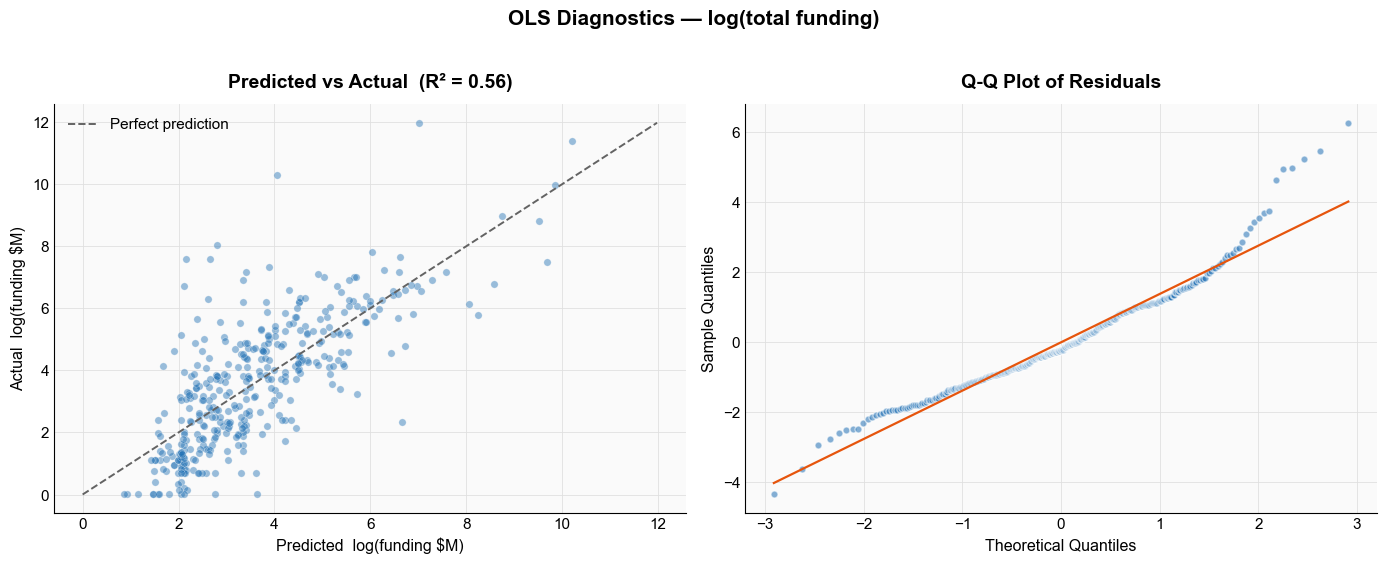

Saved: outputs/figures/07_predicted_vs_actual.png


In [27]:
from scipy import stats

y_pred = ols_model.predict(X_ols)
resid  = y_log - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(y_pred, y_log, alpha=0.45, s=28, color=BLUE,
                edgecolors='white', linewidths=0.4)
lo, hi = min(y_pred.min(), y_log.min()), max(y_pred.max(), y_log.max())
axes[0].plot([lo, hi], [lo, hi], '--', color=GREY, linewidth=1.4, label='Perfect prediction')
axes[0].set_xlabel('Predicted  log(funding $M)')
axes[0].set_ylabel('Actual  log(funding $M)')
axes[0].set_title(f'Predicted vs Actual  (R² = {ols_model.rsquared:.2f})')
axes[0].legend(loc='upper left', frameon=False)

stats.probplot(resid, dist='norm', plot=axes[1])
axes[1].get_lines()[0].set_markerfacecolor(BLUE)
axes[1].get_lines()[0].set_markeredgecolor('white')
axes[1].get_lines()[0].set_alpha(0.55)
axes[1].get_lines()[0].set_markersize(5)
axes[1].get_lines()[1].set_color(ORANGE)
axes[1].get_lines()[1].set_linewidth(1.6)
axes[1].set_title('Q-Q Plot of Residuals')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')

plt.suptitle('OLS Diagnostics — log(total funding)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/07_predicted_vs_actual.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/07_predicted_vs_actual.png')

---
## 3: Logistic Predicting Mega-Rounds ($50M+)

In [29]:
logit_model, logit_coef = fit_logit_with_or(X_logit, y_mega, feature_names=list(FEATURES.keys()))

pseudo_r2 = 1 - logit_model.llf / logit_model.llnull
print(f'Pseudo R² = {pseudo_r2:.3f}   |   AIC = {logit_model.aic:.0f}   |   n = {int(logit_model.nobs)}')
print('\n── Odds ratios (95% CI) ──')
tbl = (logit_coef
       .assign(or_str=lambda d: d['estimate'].round(2).astype(str)
                       + ' [' + d['lo'].round(2).astype(str)
                       + ', ' + d['hi'].round(2).astype(str) + ']')
       [['feature','or_str','pval','sig']]
       .rename(columns={'or_str':'OR [95% CI]'}))
print(tbl.to_string(index=False))

Pseudo R² = 0.324   |   AIC = 373   |   n = 384

── Odds ratios (95% CI) ──
             feature       OR [95% CI]         pval   sig
            Bay Area 0.85 [0.38, 1.89] 6.903519e-01 False
USA (excl. Bay Area) 6.91 [3.4, 14.01] 8.629619e-08  True
              London  2.03 [0.8, 5.15] 1.376192e-01 False
                 NYC 0.15 [0.04, 0.55] 4.193831e-03  True
   Top-Tier Investor 1.41 [0.79, 2.51] 2.470671e-01 False
       Enterprise AI  0.41 [0.2, 0.85] 1.672792e-02  True
            Agent AI 0.82 [0.22, 3.09] 7.676119e-01 False
               MLOps 0.79 [0.32, 1.95] 6.145556e-01 False
           Health AI   0.9 [0.4, 2.03] 8.012896e-01 False
          Finance AI 0.92 [0.46, 1.86] 8.217758e-01 False
   Company Age (yrs)  1.1 [1.03, 1.18] 4.490940e-03  True
    Number of Rounds  1.73 [1.4, 2.13] 3.769958e-07  True


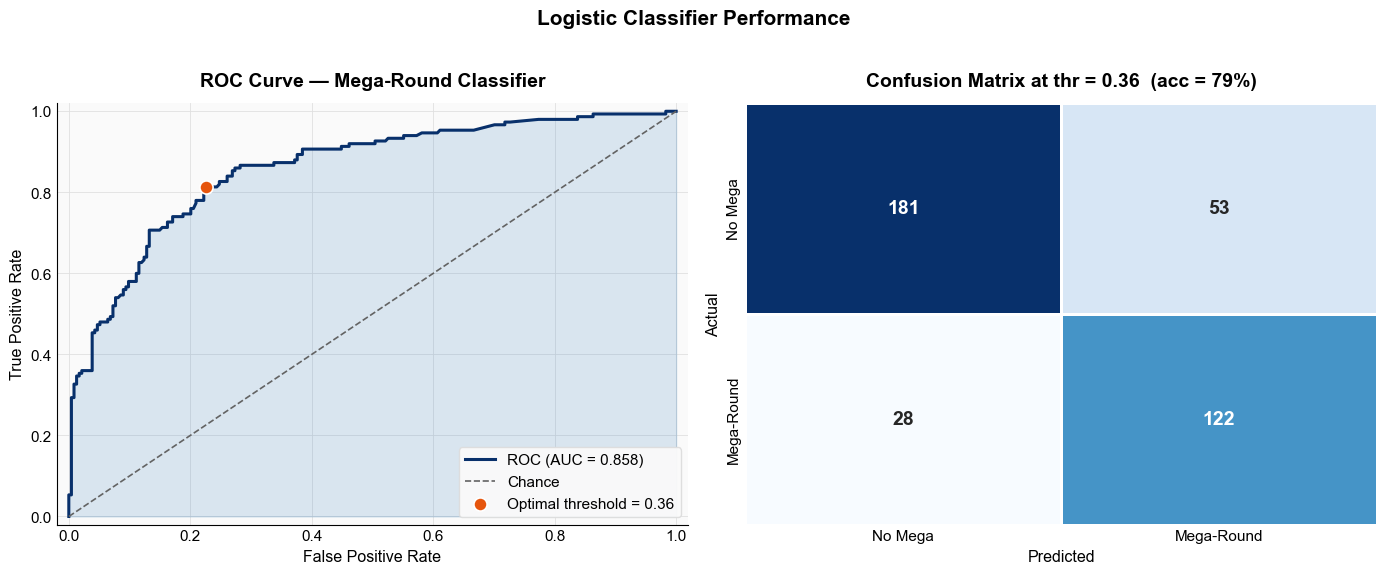

Saved → outputs/figures/08_roc_curve.png
AUC = 0.858   |   Accuracy = 78.9%   |   Sensitivity = 81.3%   |   Specificity = 77.4%


In [31]:
y_proba = logit_model.predict(X_logit)
fpr, tpr, thr = roc_curve(y_mega, y_proba)
auc_val = auc(fpr, tpr)

j_idx = np.argmax(tpr - fpr)
thr_opt = thr[j_idx]
y_hat   = (y_proba >= thr_opt).astype(int)
cm      = confusion_matrix(y_mega, y_hat)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

axes[0].plot(fpr, tpr, color=NAVY, linewidth=2.2, label=f'ROC (AUC = {auc_val:.3f})')
axes[0].fill_between(fpr, tpr, alpha=0.15, color=BLUE)
axes[0].plot([0, 1], [0, 1], '--', color=GREY, linewidth=1.2, label='Chance')
axes[0].scatter([fpr[j_idx]], [tpr[j_idx]], s=90, color=ORANGE, zorder=5,
                edgecolors='white', linewidth=1.2,
                label=f'Optimal threshold = {thr_opt:.2f}')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Mega-Round Classifier')
axes[0].legend(loc='lower right', frameon=True, edgecolor='#dddddd', framealpha=0.95)
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)

labels = ['No Mega', 'Mega-Round']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels, ax=axes[1],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'},
            linewidths=1, linecolor='white')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
tn, fp, fn, tp = cm.ravel()
acc = (tp + tn) / cm.sum()
axes[1].set_title(f'Confusion Matrix at thr = {thr_opt:.2f}  (acc = {acc:.0%})')

plt.suptitle('Logistic Classifier Performance',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/08_roc_curve.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/08_roc_curve.png')
print(f'AUC = {auc_val:.3f}   |   Accuracy = {acc:.1%}   |   '
      f'Sensitivity = {tp/(tp+fn):.1%}   |   Specificity = {tn/(tn+fp):.1%}')

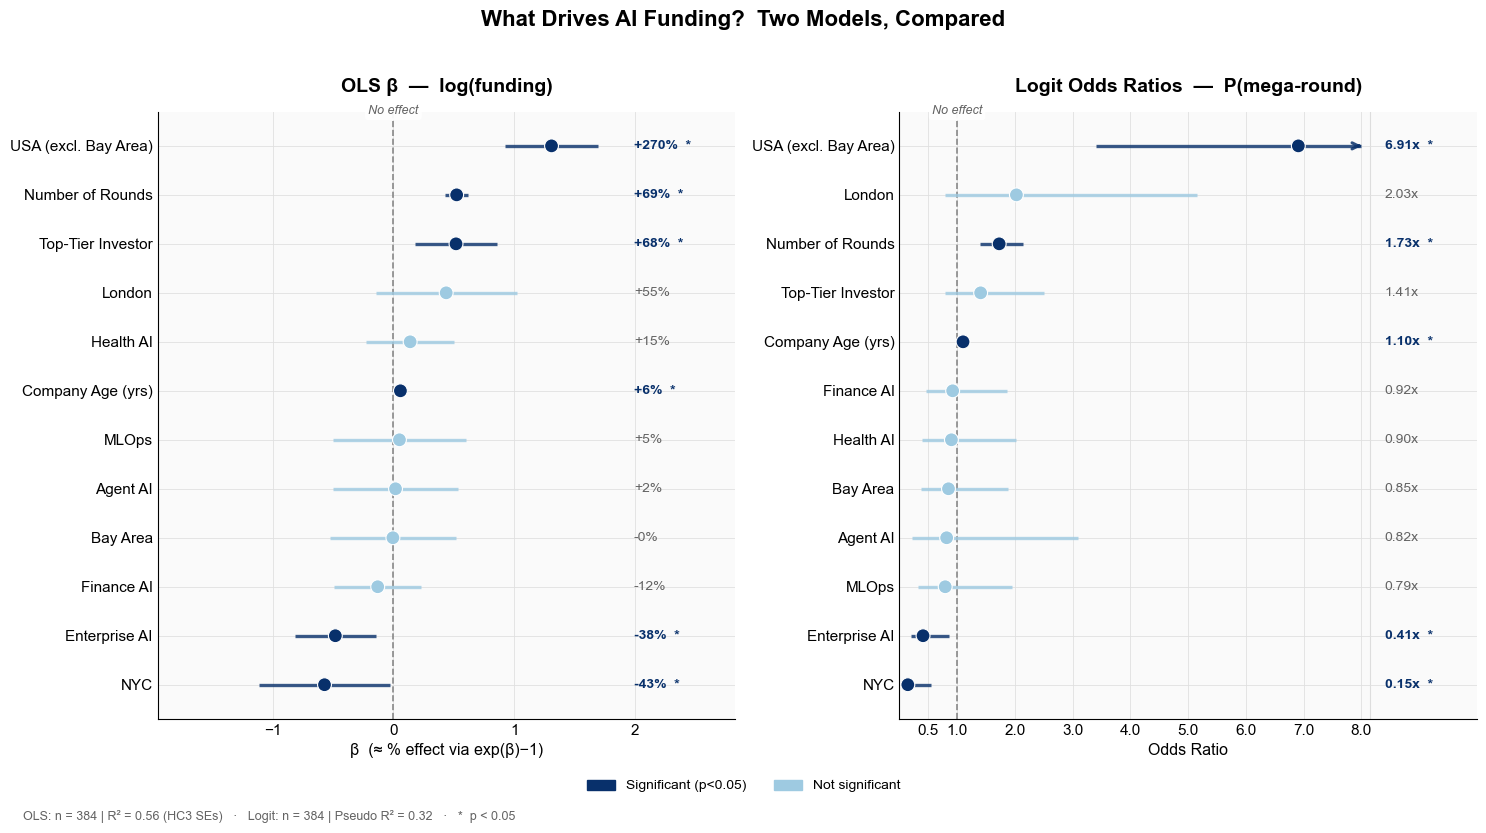

Saved → outputs/figures/06_coefficient_plot.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))

# Left: OLS coefficients (β, ref = 0)
ols_sorted = ols_coef.sort_values('estimate', ascending=True).reset_index(drop=True)
coef_forest_plot(
    ols_sorted, ax=axes[0],
    estimate_col='estimate', lo_col='lo', hi_col='hi',
    ref_value=0.0, ref_label='No effect',
    sig_color=NAVY, ns_color=LBLUE,
    title='OLS β  —  log(funding)',
)
axes[0].set_xlabel('β  (≈ % effect via exp(β)−1)')
x_max_ols = max(abs(ols_sorted['lo'].min()), abs(ols_sorted['hi'].max())) * 1.15
axes[0].set_xlim(-x_max_ols, x_max_ols * 1.45)
for i, row in ols_sorted.iterrows():
    pct = (np.exp(row['coef']) - 1) * 100
    star = '  *' if row['sig'] else ''
    color = NAVY if row['sig'] else GREY
    weight = 'bold' if row['sig'] else 'normal'
    axes[0].text(x_max_ols * 1.02, i, f'{pct:+.0f}%{star}',
                 va='center', ha='left', fontsize=10,
                 color=color, fontweight=weight)

# Right: Logit odds ratios
logit_sorted = logit_coef.sort_values('estimate', ascending=True).reset_index(drop=True)
X_MAX_OR = 8.0
coef_forest_plot(
    logit_sorted, ax=axes[1],
    estimate_col='estimate', lo_col='lo', hi_col='hi',
    ref_value=1.0, ref_label='No effect',
    x_max=X_MAX_OR,
    sig_color=NAVY, ns_color=LBLUE,
    title='Logit Odds Ratios  —  P(mega-round)',
)
axes[1].set_xlabel('Odds Ratio')
axes[1].set_xlim(0, X_MAX_OR + 2.0)
axes[1].set_xticks([0.5, 1, 2, 3, 4, 5, 6, 7, 8])
axes[1].axvline(X_MAX_OR + 0.15, color='#dddddd', linewidth=0.8, zorder=0)
for i, row in logit_sorted.iterrows():
    odds = row['estimate']
    or_str = f'{odds:.2f}x' if odds < 10 else f'{odds:.1f}x'
    star = '  *' if row['sig'] else ''
    color = NAVY if row['sig'] else GREY
    weight = 'bold' if row['sig'] else 'normal'
    axes[1].text(X_MAX_OR + 0.4, i, or_str + star,
                 va='center', ha='left', fontsize=10,
                 color=color, fontweight=weight)

plt.suptitle('What Drives AI Funding?  Two Models, Compared',
             fontsize=16, fontweight='bold', y=1.02)

sig_patch = mpatches.Patch(color=NAVY,  label='Significant (p<0.05)')
ns_patch  = mpatches.Patch(color=LBLUE, label='Not significant')
fig.legend(handles=[sig_patch, ns_patch],
           loc='lower center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.04), fontsize=10)

fig.text(0.02, -0.06,
         f'OLS: n = {int(ols_model.nobs)} | R² = {ols_model.rsquared:.2f} (HC3 SEs)   ·   '
         f'Logit: n = {int(logit_model.nobs)} | Pseudo R² = {pseudo_r2:.2f}   ·   '
         f'*  p < 0.05',
         fontsize=9, color=GREY)

plt.tight_layout()
plt.savefig('../outputs/figures/06_coefficient_plot.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/06_coefficient_plot.png')